# Deep model implementation
---
In this notebook we will start by developing the deep learning models, our approach is as follow:
1. **Char-CNN** (baseline) - Multiscale convolution architecture
2. **CNN +BiLSTM** a hypbrid CNN-RNN for char sequence modeling
3. **FastText + CNN** - a subword n-gram embedding offers a lightweight approach suitable for our CPU only constrain
4.  **Hybrid Feature Fusion** Deep features based on Random forest feature importance analysis + statistical features (length, entropy, special char ratio) → Fusion



###  Outcomes
- Performance comparison across models (accuracy, precision, recall, F1)
- Model size vs. performance tradeoff analysis
- False positive/negative analysis


# Imports and configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
# deep model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader , WeightedRandomSampler

#evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)



from tqdm import tqdm
import math
import re
import hashlib

# configurations
np.random.seed(42)
torch.manual_seed(42)

# training
batch_size = 256
MAX_LEN = 200

# Loading the training dataset & Intial setting
For the preprocessing refer to the data folder

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,URL,Label
0,https://connect.facebook.net/robots.txt,0
1,https://ir.netflix.net/investor-news-and-event...,0
2,https://elpais.com/acervo/2013-11-29/,0
3,https://www.oracle.com/a/ocom/docs/application...,0
4,https://www.w3.org/2000/svg%20viewBox=0%200%20...,0
...,...,...
90838,https://guardiandashboardv2.firebaseapp.com/,1
90839,https://bemblogado.com.br/?to=symonavolpi@yaho...,1
90840,https://pub-6e725f1502ed4cdca06e4079c3f088b1.r...,1
90841,https://aol-104727.weeblysite.com/,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90843 entries, 0 to 90842
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URL     90843 non-null  object
 1   Label   90843 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.4+ MB


In [5]:
df['Label'].value_counts()

,count
Label,
0,52480
1,38363


In [6]:
df['URL_len']= df['URL'].apply(len)

In [7]:
df['URL_len'].describe()

,URL_len
count,90843.000000
mean,78.309171
std,127.302557
min,11.000000
25%,38.000000
50%,56.000000
75%,87.000000
max,25515.000000


25515 seems to be an outlier

In [8]:
df[df['URL_len'] > 6000]

,URL,Label,URL_len
48426,https://authjgxszcloxpnassocl.web.app/hashsso/...,1,25515


it is an outlier we need to check the distribution

In [9]:
df[df['URL_len'] > 2000]

,URL,Label,URL_len
5297,https://nh-dpu.pages.dev/%5C%5C%5Chttps:%5C/%5...,1,2165
14208,https://vbp.pages.dev/%5C%5C%5Chttps:%5C/%5C/6...,1,2564
31530,https://b4e921f0.sso-mailsrvr-4344e5teed.pages...,1,5795
35342,https://bg3.pages.dev/%5C%5C%5Chttps:%5C/%5C/6...,1,2165
35954,http://nh-dpu.pages.dev/%5C%5C%5Chttps:%5C/%5C...,1,2164
38308,http://yandex.ru/clck/jsredir?from=yandex.ru%3...,1,3654
45012,https://vb-ezk.pages.dev/%5C%5C%5Chttps:%5C/%5...,1,3441
48426,https://authjgxszcloxpnassocl.web.app/hashsso/...,1,25515
61112,http://cbv.pages.dev/%5C%5C%5Chttps:%5C/%5C/6....,1,2167
61561,https://vb-ezk.pages.dev/%5C%5C%5Chttps:%5C/%5...,1,2165


above 2000 here is also an outlier but notice the majority of very long URL are Labeled 1 they are spam this is not a data erorr it is a real value and this shows that the URL length is an improtant feature that will be useful in the hybrid deep feature fusion model.

In [10]:
df[df['URL_len'] > 1000]['Label'].value_counts()

,count
Label,
0,156
1,17


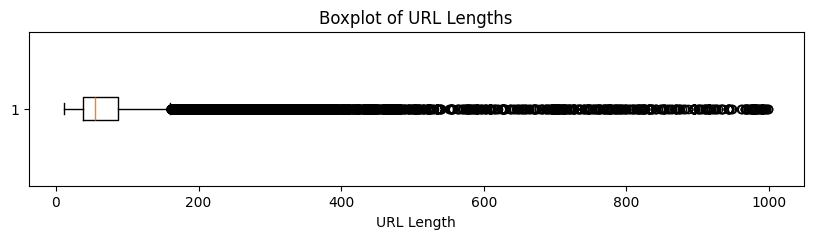

In [11]:
plt.figure(figsize=(10, 2))


data = df.loc[df['URL_len'] < 1000, 'URL_len']

plt.boxplot(data, vert=False)
plt.xlabel("URL Length")
plt.title("Boxplot of URL Lengths")
plt.show()

Box plot shows alot of outliers are above 200 in URL length and median is nearly at 50

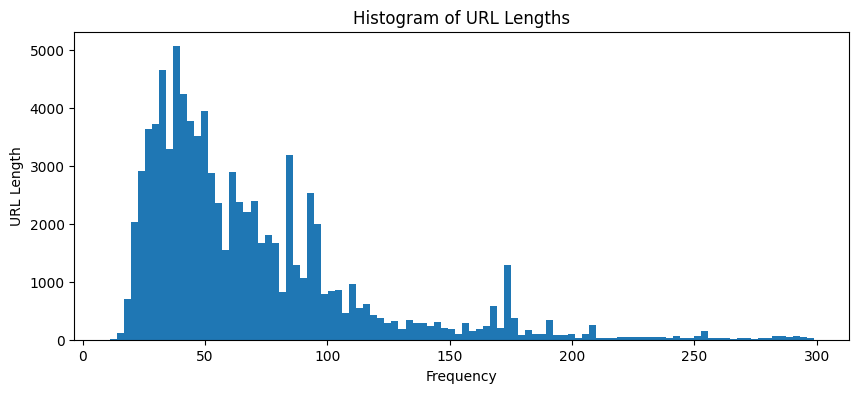

In [12]:
plt.figure(figsize=(10, 4))

data = df.loc[df['URL_len'] < 300, 'URL_len']

plt.hist(data, bins=100)
plt.ylabel("URL Length")
plt.xlabel("Frequency")
plt.title("Histogram of URL Lengths")

plt.show()

even after trimming extreme values the dataset is heavily right skewed
- For CNN we need fixed input size so we need to truncate to a max length and pad short URL since our data set has a median around 50 and alot of extreme value so a treshold of 200 would be suitable

In [13]:
train_df = df
val_df = pd.read_csv("val.csv")

In [14]:
class_counts = train_df['Label'].value_counts()

In [15]:
class_counts

,count
Label,
0,52480
1,38363


# Character Vocabulary Builder

In [16]:
class CharVocab:
  """ Building the char vocabulary from the URL dataset"""

# class constructior with default vocab size of 128 and minimum frequency of 5
  def __init__(self,max_vocab_size = 128 , min_freq =5):
    self.max_vocab_size = max_vocab_size # we should set a max_voacb size to avoid exploded dictionary
    self.min_freq = min_freq # the minimum frequency below which the word is considered too infrequent to include
    self.char2idx = {} # the dictionalry maping characters to index
    self.idx2char = {} # the oposite
    self.pad_idx = 0 # the padding index is 0
    self.unkown_idx=1 # the unkown character index is 1

  def build(self, texts):
    char_counts = Counter()
    for text in texts:
      char_counts.update(text)

    chars = [ch for ch, cnt in char_counts.items() if cnt >= self.min_freq] # only keep chars satisfying frequency treshold
    chars = sorted(chars)[:self.max_vocab_size] # after sorting only keep the max vocab size allowed

    self.char2idx = { '<PAD>': 0 , '<UNK>' : 1}
    self.idx2char = {0: '<PAD>', 1:'<UNK'}

    for ch in chars:
      idx = len(self.char2idx)
      self.char2idx[ch] = idx # map index to char
      self.idx2char[idx] = ch # map char ot index

    print(f"Vocabulary size: { len(self.char2idx)}")
    return self

# function to encode text characters to their word implementation
  def encode(self , text , max_len =None , pad_to_max = False):
    # get the indices of the given text characters to encode
    indices = [self.char2idx.get(ch,self.unkown_idx) for ch in text]
    if max_len and pad_to_max:
      if len(indices) > max_len:
        indices = indices[:max_len] # trim the extra
      elif len(indices) < max_len:
        indices = indices +[self.pad_idx] * (max_len - len(indices))# pad if shorter
    return indices

# function to decode
def decode (self, indices):
  return ''.join([self.idx2char.get(i,'<UNK') for i in indices])

Build the vocab

In [17]:
vocab = CharVocab(max_vocab_size= 100 , min_freq =3)
vocab.build(train_df['URL'].values)

Vocabulary size: 92


The vocab size actually is less than 100 so nothing is trimmed

In [18]:
print(f"fixed max length: { MAX_LEN}")

fixed max length: 200


# creating pytorch dataset

In [21]:
class URLDataset(Dataset):
  """ Pytorch Dataset for URL classification"""

  def __init__ (self, df, vocab, max_len=200 , augment =False):# the class constractor taking dataset , vocab and max_length , also augment
    self.urls = df['URL'].values
    self.labels = df['Label'].values
    self.vocab = vocab
    self.max_len = max_len
    self.augment = augment
 # overwriting the Dataset Class len function
  def __len__(self):
    return len(self.urls)
  # overwriting the get item function
  def __getitem__(self,idx):
    url = self.urls[idx] # get url by index from the urls dictionary
    label = self.labels[idx]  # get label by index from the label dictionary
    encoded = self.vocab.encode(url, self.max_len, pad_to_max =True)#encode the url

    if self.augment and np.random.random() < 0.1: # augmentation happend occationally with probability 10%
      mask = np.random.random(len(encoded))<0.05 # lonly 5% of tokens are set to true in the mask
      for i in range(len(encoded)):
        if mask[i] and encoded[i]>1: # the index is selected by mask and encoded value is greater than one to avoid modifying pad 0 or unknown 1
          encoded[i] = self.vocab.unkown_idx  # replace the selected to token with unknown_idx 1 to make the model more robust

    return torch.tensor(encoded,dtype= torch.long), torch.tensor(label, dtype = torch.float) # convert lables to float tensor first tensor of encoded long as characters are encoded as whole numbers and might be larger than integer url and second is encoded float lable 0.0 or 1.0 as precidtionis will be between 0 and 1 so that binary cross enntropy functin apply


In [22]:

# Create datasets
train_dataset = URLDataset(train_df, vocab, MAX_LEN, augment=True)
val_dataset = URLDataset(val_df, vocab, MAX_LEN, augment=False)

# Handle class imbalance with weighted sampler
class_weights = {0: 1.0/class_counts[0], 1: 1.0/class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['Label'].values]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# Create dataloaders
#batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2) # shuffle by default to avoid learinging meaningless order
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2) # no learning shuffle is unnessary

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 355, Val batches: 77


training set size = 90000 / 256 ~ 351 with  padding 355 which is a rational increase

# Char CNN

In [41]:
class CharCNN(nn.Module):
  """ Character-level CNN with multi-scale kernels"""
  # create charCNN constructor
  def __init__(self , vocab_size, embed_dim = 64, num_filters=128, kernel_sizes=[3,5,7], dropout=0.3):
  # since we have a batch size of 256 URL each is padded or truncated to length 200 token each token is represented by 64 embedding vector the resulting tensor is [256,200,64]
    super(CharCNN, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embed_dim , padding_idx = 0) # embedding layer

    # three 1D convlution layers each look at different subset using kernels  of 3 , 5 , 7 to capture diffent url words
    self.convs = nn.ModuleList([
        nn.Conv1d(embed_dim , num_filters, k, padding = k//2)
        for k in kernel_sizes
    ])

    # batch normalization for each of the three kernel each has 128 filter /feature
    self.batch_norms = nn.ModuleList([
        nn.BatchNorm1d(num_filters) for _ in kernel_sizes
    ])

    # apply dropout to stablize training and prvent overfitting
    self.dropout = nn.Dropout(dropout)

    # the fully connected layer
    conv_out_size = num_filters * len(kernel_sizes) # 128 * 3
    self.fc1 = nn.Linear(conv_out_size,128)
    # the output layer mapping the 128 to 1 output it is linear to get
    self.fc2 = nn.Linear(128,1)

  def forward(self, x):
    x = self.embedding(x)
    x = x.permute(0,2,1) # as convolution layer expect (256 , 64 , 200 ) ( batch size, embedding , max sequence length)

    conv_outputs = []
    # applying the forward pass for batch x
    for conv, bn in zip(self.convs ,self.batch_norms):
      conv_out = conv(x)
      conv_out = bn(conv_out)
      conv_out = F.relu(conv_out)
      # each filter become one number per URL in batch
      conv_out = F.max_pool1d(conv_out, conv_out.size(2)) # max pooling keep the strongest feature for each token instead of keeping the 200 tokens only the 128 vector is preserved with single max value indicating wether this feature appeared at all not its position
      conv_out = conv_out.squeeze(2) # removing the unnessary 3rd dimesion of 1 it is a matrix now

      conv_outputs.append(conv_out) # list of tensors for each kernel

    x = torch.cat(conv_outputs, dim=1) # combine conv_ouputs in one tensor [batch , 128*3]features
    x = self.dropout(x) # apply drop out
    x = F.relu(self.fc1(x)) # relu fully connected layer 1 to reduce 128*3 to 128
    x = self.dropout(x) # dropout
    x = self.fc2(x)  # fully connected layer 2 to produce output 128 to 1
    return x.squeeze(1) # remove the extra dimension


In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
char_cnn = CharCNN(vocab_size=len(vocab.char2idx)).to(device)
print(f"CharCNN parameters: {sum(p.numel() for p in char_cnn.parameters()):,}")

CharCNN parameters: 179,329


In [43]:
class EarlyStopping:
  def __init__(self, patience = 5, min_delta = 0.001 ):
    self.patience = patience   # number of epochs if value didn't change stop
    self.min_delta = min_delta  # minimum change counted significant
    self.counter = 0  # counter to track if patience treshold is reaced
    self.best_score = None # track best validation score sofar


  def __call__(self, val_loss):
    if self.best_score is None:
      self.best_score = val_loss # best score found so far
    elif val_loss > self.best_score - self.min_delta: # validation loss is larger than the allowed treshold
      self.counter +=1 # increasing counter value
      if self.counter >= self.patience: # more than or equal patience
        self.early_stopping = True # trigger early stopping
      else:
        self.best_score = val_loss # save best value
        self.counter = 0 # reset counter
      return self.early_stopping




In [44]:
def train_epoch(model ,loader, optimizer, criterion, device):
  model.train()
  total_loss = 0
  all_preds = []
  all_labels = []

  for batch in tqdm(loader, desc ='Trainig'): # tqdm to print progress while training is running

      x, y = batch
      x, y = x.to(device), y.to(device) # move data to cpu or Gpu
      optimizer.zero_grad() # clear old gradient before calculating new one it is saved by defualt
      outputs = model(x) # feed batch to model

      loss = criterion(outputs, y) # calculate error with BCEWithLogitsLoss
      loss.backward() # compute model with respect to all model parameters
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #limit gradient to maximum norm 1 prevent exploding gradients
      optimizer.step() # update weights with optimizer

      total_loss += loss.item() # save total batch loss
      preds = (torch.sigmoid(outputs) > 0.5).float() # convert logits to predictions 1 or 0
      all_preds.extend(preds.cpu().numpy()) # move preds to cpu or gpu
      all_labels.extend(y.cpu().numpy()) # store actual labels for metric computation

  return total_loss / len(loader), all_preds, all_labels


In [45]:
def evaluate(model,loader,criterion, device):
  model.eval()
  total_loss = 0
  all_preds = []
  all_labels = []

  with torch.no_grad(): # no gradient is needed in evaluation phase
    for batch in tqdm(loader , desc="evaluation"):
        x, y = batch
        x, y = x.to(device), y.to(device)
        outputs = model(x)

        loss = criterion(outputs, y)
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return total_loss / len(loader), all_preds, all_labels


In [46]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
    }

In [47]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001,
                weight_decay=1e-4): # default values are used

    pos_weight = torch.tensor([class_counts[0]/class_counts[1]]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) # adam optimizer used
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    early_stopping = EarlyStopping(patience=5)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    print(f"\n{'='*50}")
    print(f"Training Char-CNN")
    print(f"{'='*50}")

    for epoch in range(epochs): # at each epoch
       # train epoch
        train_loss, train_preds, train_labels = train_epoch(
            model, train_loader, optimizer, criterion, device
        )
        # evaluate epoch
        val_loss, val_preds, val_labels = evaluate(
            model, val_loader, criterion, device
        )

        # compute and save metrics

        train_metrics = compute_metrics(train_labels, train_preds)
        val_metrics = compute_metrics(val_labels, val_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_metrics['F1'])

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_metrics['Accuracy']:.4f}, F1: {train_metrics['F1']:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Acc: {val_metrics['Accuracy']:.4f}, F1: {val_metrics['F1']:.4f}")

        scheduler.step(val_loss)
        if early_stopping(val_loss): # show if early stopping is triggered
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return history, val_metrics

# Model 1: Char-CNN

In [48]:

char_cnn = CharCNN(vocab_size=len(vocab.char2idx)).to(device)
history_cnn, metrics_cnn = train_model(
    char_cnn, train_loader, val_loader, epochs=15
)


Training Char-CNN


evaluation: 100%|██████████| 77/77 [00:29<00:00,  2.62it/s]


Epoch 1/15
  Train Loss: 0.2360, Acc: 0.9157, F1: 0.9168
  Val Loss: 0.0896, Acc: 0.9704, F1: 0.9655


evaluation: 100%|██████████| 77/77 [00:29<00:00,  2.63it/s]


Epoch 2/15
  Train Loss: 0.1190, Acc: 0.9620, F1: 0.9620
  Val Loss: 0.0674, Acc: 0.9810, F1: 0.9773


...

Epoch 13/15
  Train Loss: 0.0286, Acc: 0.9915, F1: 0.9915
  Val Loss: 0.0309, Acc: 0.9913, F1: 0.9896


evaluation: 100%|██████████| 77/77 [00:30<00:00,  2.56it/s]


Epoch 14/15
  Train Loss: 0.0280, Acc: 0.9913, F1: 0.9914
  Val Loss: 0.0300, Acc: 0.9914, F1: 0.9899


evaluation: 100%|██████████| 77/77 [00:32<00:00,  2.38it/s]


Epoch 15/15
  Train Loss: 0.0275, Acc: 0.9916, F1: 0.9916
  Val Loss: 0.0293, Acc: 0.9912, F1: 0.9896


**Comment:**
The model is showing strong generalization and stable converging through the epochs however it is worth noting that the training accuracy in early epochs are less than validation this is normal and expected due to applying augmentation and dropout which makes the training instances more challenging but enables the model to learn robustly and stablly even in presenece of noise which is reflected in the validation accuracy.

saving model to avoid rerunning and restart kernel to utlize availabel computing resources to the max.

In [49]:
torch.save(char_cnn.state_dict(), "char_cnn_model1.pth")

In [50]:
results = {
    'Model': ['Char-CNN'],
    'Params (M)': [sum(p.numel() for p in char_cnn.parameters()) / 1e6,],
    'Accuracy': [ metrics_cnn['Accuracy']],
    'Precision': [ metrics_cnn['Precision']],
    'Recall': [ metrics_cnn['Recall']],
    'F1 Score': [ metrics_cnn['F1'] ]
}

comparison_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL PERFORMANCE ")
print("="*70)
print(comparison_df.to_string(index=False))

# Efficiency (F1 per million params)
print("\n" + "-"*50)
print("EFFICIENCY ANALYSIS (F1 Score per Million Parameters)")
print("-"*50)
for i, row in comparison_df.iterrows():
    efficiency = row['F1 Score'] / row['Params (M)']
    print(f"{row['Model']:15} : {efficiency:.2f}")


MODEL PERFORMANCE 
   Model  Params (M)  Accuracy  Precision   Recall  F1 Score
Char-CNN    0.179329  0.991215   0.985992 0.993309  0.989637

--------------------------------------------------
EFFICIENCY ANALYSIS (F1 Score per Million Parameters)
--------------------------------------------------
Char-CNN        : 5.52
